# Photonic QGAN — Demo Notebook

**Paper:** *Photonic quantum generative adversarial networks for classical data* (Optica Quantum, 2025)  
**Authors:** Tigran Sedrakyan, Alexia Salavrakos — Quandela  
**DOI:** https://arxiv.org/abs/2405.06023

---

## Background

### Generative Adversarial Networks (GANs)
A GAN consists of two neural networks trained in opposition:
- **Generator G** — learns to produce fake samples that resemble real data.
- **Discriminator D** — learns to distinguish real samples from generated (fake) ones.

They play a *minimax game*: G tries to fool D, while D tries not to be fooled. At convergence, G ideally produces indistinguishable samples.

### Quantum GANs (QGANs)
A QGAN replaces the classical generator with a *parametrised quantum circuit* (PQC). The PQC's trainable rotation angles are optimised end-to-end via backpropagation. The discriminator stays classical.

### Why Photonic?
This paper uses **linear-optical circuits** instead of qubit circuits:
- **Fock-space encoding** — input photon occupation numbers are the data carriers.
- **Near-term compatibility** — linear optics + single-photon sources are the strongest near-term photonic platform.
- **Patch generation** — each optical circuit generates one patch of the output image; multiple circuits tile the full image.

![Photonic QGAN architecture overview](./photonicQGAN.png)

### This demo
We run a short ideal (noiseless) simulation using:
- **Setup:** `setup_c` — one of four pre-defined linear-optical layouts  
- **Input Fock state:** `[0, 1, 0, 1, 0]` — two photons in a 5-mode circuit  
- **Optimizer:** Adam (replacing the original paper's SPSA)  
- **Target digit:** `0` from the Optdigits dataset  
- **Iterations:** 800 (use 1000+ for a full reproduction run)

In [ ]:
from __future__ import annotations

import importlib.util
import json
import shutil
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# If your notebook kernel is missing project dependencies, uncomment the next line.
# %pip install -r requirements.txt

required_modules = {
    "loguru": "loguru",
    "matplotlib": "matplotlib",
    "skimage": "scikit-image",
    "torchvision": "torchvision",
    "merlin": "merlinquantum",
    "perceval": "perceval-quandela",
}
missing_modules = [
    package_name
    for import_name, package_name in required_modules.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_modules:
    raise ModuleNotFoundError(
        "Missing notebook dependencies: "
        + ", ".join(missing_modules)
        + ". Install them with `%pip install -r requirements.txt` from `papers/photonic_QGAN`."
    )

cwd = Path.cwd().resolve()
candidate_dirs = [cwd, cwd / "papers" / "photonic_QGAN"]
PROJECT_DIR = None
for candidate in candidate_dirs:
    if (candidate / "configs" / "ideal_selectable_top3_run_20260213-104332.json").exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate `papers/photonic_QGAN` from the current working directory."
    )

REPO_ROOT = PROJECT_DIR.parent.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from lib.runner import train_and_evaluate
from runtime_lib.config import load_config
from runtime_lib.dtypes import DtypeSpec, resolve_config_dtypes

def make_json_safe(node):
    if isinstance(node, DtypeSpec):
        return node.label
    if isinstance(node, dict):
        return {key: make_json_safe(value) for key, value in node.items()}
    if isinstance(node, list):
        return [make_json_safe(value) for value in node]
    return node

#PROJECT_DIR


## 1 · Configuration

The config is a nested dictionary that controls every aspect of the run. The three most important sections are:

| Section | Key parameters | What it controls |
|---|---|---|
| `run` | `mode`, `runs`, `log_every` | High-level run orchestration |
| `training.ideal` | `optimizer`, `opt_iter_num`, `lrG`, `lrD`, `g_steps`, `d_steps` | Adam hyperparameters and training schedule |
| `ideal` | `setup`, `input_state`, `gen_count`, `pnr` | Photonic circuit topology and generator config |

### Key `ideal` parameters
- **`setup`** — selects one of four pre-defined beam-splitter layouts (`setup_a` … `setup_d`). Each layout differs in circuit depth and connectivity.
- **`input_state`** — Fock-state occupation numbers fed to each patch circuit, e.g. `[0, 1, 0, 1, 0]` means 2 photons in modes 1 and 3 of a 5-mode circuit.
- **`gen_count`** — number of independent patch generators that tile the output image. With `image_size = 8` and `gen_count = 4`, each circuit generates a strip that covers a quarter of the image pixels.
- **`pnr`** — whether to use photon-number-resolving (PNR) detectors (`True`) or threshold detectors (`False`). PNR gives richer output distributions but is harder to realise experimentally.

### Key `training.ideal` parameters
- **`g_steps / d_steps`** — gradient steps per iteration for G and D respectively. Using `g_steps = 3` means the generator trains 3× more often than the discriminator each iteration.
- **`real_label / fake_label`** — label smoothing: using 0.9 instead of 1.0 for real samples regularises the discriminator.
- **`gen_target`** — if G's loss falls below this threshold the generator step is skipped for that iteration, preventing over-training G early on.

In [2]:
CONFIG_PATH = PROJECT_DIR / "configs" / "ideal_selectable_top3_run_20260213-104332.json"
cfg = resolve_config_dtypes(deepcopy(load_config(CONFIG_PATH)))

cfg["seed"] = 0
cfg["data_root"] = str(REPO_ROOT / "data")
cfg["outdir"] = str(PROJECT_DIR / "results")

cfg["run"].update(
    {
        "mode": "ideal",
        "runs": 1,
        "progress": True,
        "write_to_disk": True,
        "log_every": 25,
    }
)

cfg["training"]["ideal"].update(
    {
        "optimizer": "adam",
        "d_optimizer": "adam",
        "opt_iter_num": 800,
        "lrD": 0.0002,
        "lrG": 0.004,
        "adam_beta1": 0.5,
        "adam_beta2": 0.99,
        "real_label": 0.9,
        "fake_label": 0.0,
        "gen_target": 0.9,
        "d_steps": 1,
        "g_steps": 3,
    }
)

cfg["ideal"].update(
    {
        "use_default_grid": False,
        "config_grid_path": None,
        "digit": 0,
        "setup": "setup_c",
        "input_state": [0, 1, 0, 1, 0],
        "gen_count": 4,
        "pnr": False,
    }
)

run_dir = PROJECT_DIR / "results" / "notebook_demo_setup_c_01010_adam"
if run_dir.exists():
    shutil.rmtree(run_dir)
run_dir.mkdir(parents=True, exist_ok=True)
(run_dir / "config_snapshot.json").write_text(
    json.dumps(make_json_safe(cfg), indent=2),
    encoding="utf-8",
)

demo_summary = {
    "config_path": str(CONFIG_PATH.relative_to(PROJECT_DIR)),
    "run_dir": str(run_dir.relative_to(PROJECT_DIR)),
    "setup": cfg["ideal"]["setup"],
    "input_state": cfg["ideal"]["input_state"],
    "optimizer": cfg["training"]["ideal"]["optimizer"],
    "opt_iter_num": cfg["training"]["ideal"]["opt_iter_num"],
    "lrD": cfg["training"]["ideal"]["lrD"],
    "lrG": cfg["training"]["ideal"]["lrG"],
}
demo_summary


{'config_path': 'configs/ideal_selectable_top3_run_20260213-104332.json',
 'run_dir': 'results/notebook_demo_setup_c_01010_adam',
 'setup': 'setup_c',
 'input_state': [0, 1, 0, 1, 0],
 'optimizer': 'adam',
 'opt_iter_num': 800,
 'lrD': 0.0002,
 'lrG': 0.004}

## 2 · Training

### Architecture recap

```
noise z  ──►  PatchGenerator G  ──►  fake image
                  │                       │
         (4 × QuantumLayer,               ▼
          one per image patch)    Discriminator D ──► P(real)
```

**`PatchGenerator`** contains `gen_count = 4` independent `QuantumLayer` instances. Each is backed by a `ParametrizedQuantumCircuit` built from the chosen setup. The circuit outputs a photon-count probability distribution over output modes; these probabilities are mapped to pixel values and stitched into a full image.

**`Discriminator`** is a small fully-connected network that outputs a single scalar: the probability that its input is a real image.

### Training loop (per iteration)
1. Sample a mini-batch of real digit-0 images from Optdigits.
2. **D step** (`d_steps = 1`): update D with binary cross-entropy, using soft labels (real = 0.9, fake = 0.0).
3. **G step** (`g_steps = 3`): update G by back-propagating through D with target label = 1.0 (fool D). This is repeated 3× per D step to give G more gradient signal early in training.

Every `log_every = 25` iterations the runner writes `loss_progress.csv`, `ssim_progress.csv`, and `fake_progress.csv` into the run directory.

> **Runtime note:** each iteration involves 4 photonic circuit evaluations (one per patch), so 800 iterations takes a few minutes on a laptop in ideal (CPU-simulated) mode.

In [3]:
train_and_evaluate(cfg, run_dir)

result_candidates = sorted(run_dir.glob("ideal-*/*/config_*_input_*/run_*"))
if not result_candidates:
    log_path = run_dir / "qgan.log"
    if log_path.exists():
        log_tail = "\n".join(
            log_path.read_text(encoding="utf-8", errors="replace").splitlines()[-40:]
        )
    else:
        log_tail = "No qgan.log found under the run directory."
    raise RuntimeError(
        "No completed run directory was produced. "
        "Check the dependency cell above and inspect the qgan.log tail below.\n\n"
        + log_tail
    )

result_dir = result_candidates[0]
sorted(path.name for path in result_dir.iterdir())


2026-03-31 09:44:31.742 | INFO     | lib.runner:train_and_evaluate:487 - Run configuration mode=ideal runs=1 write_to_disk=True progress=True log_every=25
2026-03-31 09:44:31.743 | INFO     | lib.runner:train_and_evaluate:517 - Dataset csv_path=photonic_QGAN/optdigits_csv.csv
2026-03-31 09:44:31.743 | INFO     | lib.runner:train_and_evaluate:561 - Training params opt_iter_num=800 lrD=0.0002 lrG=0.004 optimizer=adam d_optimizer=adam betas=(0.5, 0.99) labels=(real=0.9, fake=0.0, gen=0.9) steps=(d=1, g=3)
2026-03-31 09:44:31.743 | INFO     | lib.runner:train_and_evaluate:690 - Ideal mode selected setup=setup_c input_state=[0, 1, 0, 1, 0] gen_count=4 pnr=False
2026-03-31 09:44:31.744 | INFO     | lib.runner:train_and_evaluate:703 - Model batch_size=4 ideal_digits=[0]
2026-03-31 09:44:31.744 | INFO     | lib.runner:train_and_evaluate:706 - --- Ideal mode digit=0 ---
2026-03-31 09:44:37.940 | INFO     | lib.runner:train_and_evaluate:739 - Ideal digit=0 config 0 run 1/1
2026-03-31 09:44:45.05

['G_params_progress.csv',
 'G_params_progress.pt',
 'fake_progress.csv',
 'fake_progress_last.png',
 'generated_every_100',
 'loss_progress.csv',
 'ssim_progress.csv']

## 3 · Metrics

Three CSV files are written into the run directory at every logged iteration:

| File | Columns | Description |
|---|---|---|
| `loss_progress.csv` | `d_loss, g_loss` | Discriminator and generator binary cross-entropy losses per logged iteration. |
| `ssim_progress.csv` | `iteration, similarity, diversity, ssim` | Image-quality metrics evaluated on a fixed batch of generated samples. |
| `fake_progress.csv` | *(flat pixel values)* | All generated samples flattened, one row per logged iteration; used to inspect generation quality over time. |

### SSIM-based metrics
These are computed by comparing all pairs of real and fake images with the [Structural Similarity Index (SSIM)](https://en.wikipedia.org/wiki/Structural_similarity_index_measure):

- **Similarity** — average SSIM between *real* and *fake* images. Higher → generated images look more like real digit-0s.
- **Diversity** — `1 − (average SSIM between pairs of fakes)`. Higher → the generator avoids mode collapse (not producing the same image every time).
- **SSIM score** — simple average of similarity and diversity; the single scalar used to rank configurations in the hyperparameter study.

### Loss interpretation
In a well-behaved GAN, both D and G losses settle to a moderate value (~0.5–0.7) and oscillate gently. Watch for:
- **D loss → 0**: discriminator dominates; generator has not learned yet.
- **G loss → 0**: generator fools D completely; possible mode collapse.
- **Both losses stable**: healthy adversarial equilibrium.

In [4]:
loss_progress = np.loadtxt(
    result_dir / "loss_progress.csv",
    delimiter=",",
    comments="#",
)
if loss_progress.ndim == 1:
    loss_progress = loss_progress.reshape(1, -1)

ssim_path = result_dir / "ssim_progress.csv"
if ssim_path.exists():
    ssim_progress = np.loadtxt(
        ssim_path,
        delimiter=",",
        comments="#",
    )
    if ssim_progress.ndim == 1:
        ssim_progress = ssim_progress.reshape(1, -1)
else:
    ssim_progress = np.empty((0, 4))

fake_progress = np.loadtxt(result_dir / "fake_progress.csv", delimiter=",")
if fake_progress.ndim == 1:
    fake_progress = fake_progress.reshape(1, -1)

image_size = int(cfg["model"]["image_size"])
pixels_per_image = image_size * image_size
last_snapshot = fake_progress[-1]
if last_snapshot.size % pixels_per_image != 0:
    raise ValueError(
        f"Expected the flattened snapshot size to be a multiple of {pixels_per_image}, got {last_snapshot.size}."
    )
num_generated_samples = last_snapshot.size // pixels_per_image
last_samples = last_snapshot.reshape(num_generated_samples, image_size, image_size)
last_sample = last_samples[3]

summary = {
    "result_dir": str(result_dir.relative_to(PROJECT_DIR)),
    "num_iterations": int(loss_progress.shape[0]),
    "num_generated_samples_in_last_snapshot": int(num_generated_samples),
    "final_d_loss": float(loss_progress[-1, 0]),
    "final_g_loss": float(loss_progress[-1, 1]),
    "final_ssim": float(ssim_progress[-1, 3]) if ssim_progress.size else None,
}
summary


{'result_dir': 'results/notebook_demo_setup_c_01010_adam/ideal-0/setup_c/config_0_input_01010/run_1',
 'num_iterations': 800,
 'num_generated_samples_in_last_snapshot': 4,
 'final_d_loss': 1.0095332860946655,
 'final_g_loss': 0.9790595173835754,
 'final_ssim': 0.5665793729325136}

## 4 · Results

### What to look for in the plots

**Left — Training losses**  
Both curves should decrease from their initial values and eventually stabilise. Mild oscillation is normal in GAN training.

**Centre — SSIM metrics**  
- *Similarity* should increase as G learns to generate digit-like images.  
- *Diversity* should stay reasonably high (> 0.3) to confirm the generator is not collapsing to a single image.  
- The combined *SSIM* score is the key optimisation target used in the hyperparameter study.

**Right — Final generated sample**  
Shows one of the `gen_count = 4` generated samples from the last logged snapshot. A successful short run should already show a rough circular/looped shape for digit 0, even if noisy.

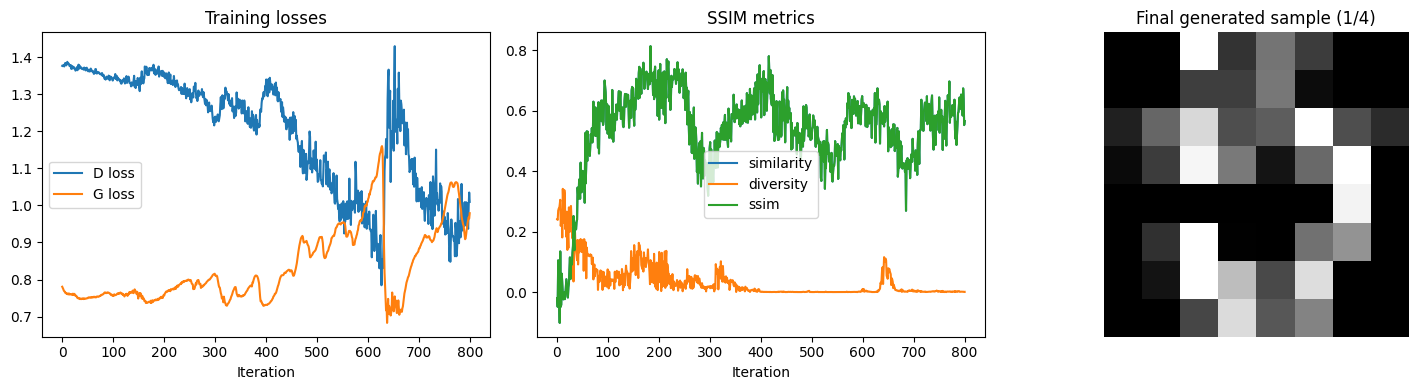

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_progress[:, 0], label="D loss")
axes[0].plot(loss_progress[:, 1], label="G loss")
axes[0].set_title("Training losses")
axes[0].set_xlabel("Iteration")
axes[0].legend()

if ssim_progress.size:
    axes[1].plot(ssim_progress[:, 0], ssim_progress[:, 1], label="similarity")
    axes[1].plot(ssim_progress[:, 0], ssim_progress[:, 2], label="diversity")
    axes[1].plot(ssim_progress[:, 0], ssim_progress[:, 3], label="ssim")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No SSIM log found", ha="center", va="center")

axes[1].set_title("SSIM metrics")
axes[1].set_xlabel("Iteration")

axes[2].imshow(last_samples, cmap="gray")
axes[2].set_title(f"Final generated sample (1/{num_generated_samples})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Next steps

### Longer run (closer to the paper)
Keep everything else the same and change:
```python
cfg["training"]["ideal"]["opt_iter_num"] = 1000
cfg["run"]["log_every"] = 100
```
The output layout stays identical, so all analysis cells above still work.

### Try a different photonic setup or input state
```python
cfg["ideal"]["setup"]        = "setup_a"           # one of setup_a / setup_b / setup_c / setup_d
cfg["ideal"]["input_state"]  = [1, 0, 1, 0, 0]    # any 2-photon 5-mode Fock state
```
Each setup has a different beam-splitter layout, which changes the expressivity of the circuit and the distribution of pixel values it can generate.

### Use PNR detectors
```python
cfg["ideal"]["pnr"] = True
```
PNR detectors resolve the exact photon number in each output mode, giving a richer probability distribution and potentially better generation quality at the cost of a larger output space.

### Run a full ideal grid
Set `ideal.use_default_grid = True` to sweep all four setups over several input states automatically and compare SSIM scores across configurations.